TensorFlow version : 2.19.0
GPU available      : False

Dataset  : 3,978 rows
Range    : 2020-09-14 → 2026-02-28
Columns  : ['Open_Time', 'Open', 'High', 'Low', 'Close', 'Volume']
Scaling done — shape: (3978, 5)

Sequences : 3,914  (lookback=60, horizon=5)
Train     : 2,740
Val       : 587
Test      : 587


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm3 (LSTM)                    │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm4 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,157 (129.52 KB)

 Trainable params: 32,965 (128.77 KB)

 Non-trainable params: 192 (768.00 B)


Training …
Epoch 1/150
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - loss: 0.1184 - mae: 0.2544 - val_loss: 0.2928 - val_mae: 0.5228 - learning_rate: 0.0010
Epoch 2/150
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0387 - mae: 0.1501 - val_loss: 0.2492 - val_mae: 0.4814 - learning_rate: 0.0010
Epoch 3/150
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - loss: 0.0233 - mae: 0.1153 - val_loss: 0.2213 - val_mae: 0.4528 - learning_rate: 0.0010
Epoch 4/150
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0173 - mae: 0.0985 - val_loss: 0.1051 - val_mae: 0.3085 - learning_rate: 0.0010
Epoch 5/150
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0130 - mae: 0.0848 - val_loss: 0.0864 - val_mae: 0.2805 - learning_rate: 0.0010
Epoch 6/150
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0107 - mae: 0.0762 - val_loss: 0.0694 - val_mae: 0.2489 - learning_rate: 0.0010
Epoch 7/150
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - loss: 0.0089 - mae: 0.0692 - val_loss: 0.0238 - val_mae: 0.1408 - learning_rate:

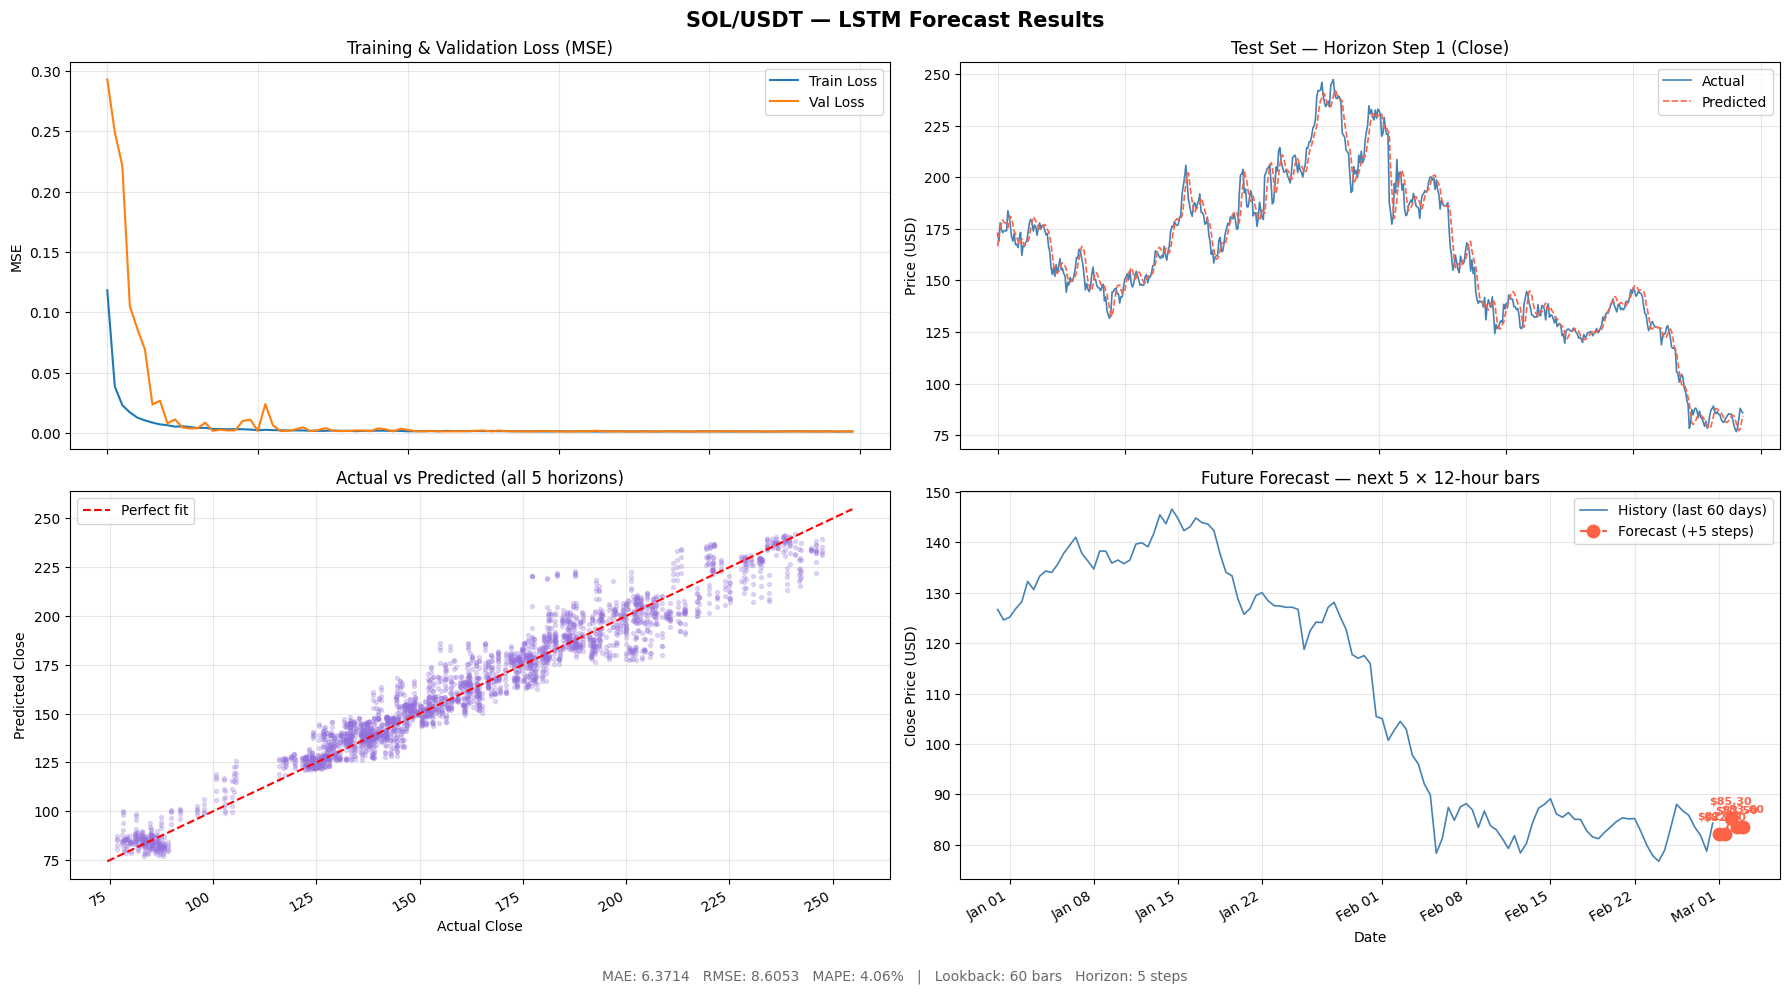

Plot saved → sol_lstm_results.png


In [2]:
# ============================================================
#  SOL/USDT LSTM Forecaster  —  Jupyter Notebook Version
#  Edit the CONFIG block below, then Run All
# ============================================================

# ── CONFIG ───────────────────────────────────────────────────
CSV_PATH   = "SOL_Historical_Master.csv"  # path to your CSV
HORIZON    = 5      # steps to forecast ahead (5–15)
LOOKBACK   = 60     # how many past bars to feed the LSTM
EPOCHS     = 150    # max training epochs (EarlyStopping will stop early)
BATCH_SIZE = 32
TEST_FRAC  = 0.15   # fraction of data for testing
VAL_FRAC   = 0.15   # fraction of data for validation
MODEL_OUT  = "sol_lstm.keras"
PRED_OUT   = "predictions.csv"
# ─────────────────────────────────────────────────────────────

import joblib
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")

# ── Constants ────────────────────────────────────────────────
FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]
TARGET_COL   = "Close"
BAR_FREQ     = pd.Timedelta("12h")

assert 2 <= HORIZON <= 5, "HORIZON must be between 5 and 15"


# ════════════════════════════════════════════════════════════
#  1. LOAD DATA
# ════════════════════════════════════════════════════════════
df = pd.read_csv(CSV_PATH, parse_dates=["Open_Time"])
df = df.sort_values("Open_Time").reset_index(drop=True)
df = df.dropna(subset=FEATURE_COLS)

print(f"\nDataset  : {len(df):,} rows")
print(f"Range    : {df['Open_Time'].min().date()} → {df['Open_Time'].max().date()}")
print(f"Columns  : {df.columns.tolist()}")
df.tail(3)


# ════════════════════════════════════════════════════════════
#  2. SCALE
# ════════════════════════════════════════════════════════════
raw    = df[FEATURE_COLS].values.astype(np.float32)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(raw)

print(f"Scaling done — shape: {scaled.shape}")


# ════════════════════════════════════════════════════════════
#  3. BUILD SEQUENCES
# ════════════════════════════════════════════════════════════
close_idx = FEATURE_COLS.index(TARGET_COL)

X_list, y_list = [], []
for i in range(len(scaled) - LOOKBACK - HORIZON + 1):
    X_list.append(scaled[i : i + LOOKBACK])
    y_list.append(scaled[i + LOOKBACK : i + LOOKBACK + HORIZON, close_idx])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

n       = len(X)
n_test  = max(1, int(n * TEST_FRAC))
n_val   = max(1, int(n * VAL_FRAC))
n_train = n - n_val - n_test

X_train, y_train = X[:n_train],               y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],  y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],         y[n_train+n_val:]

print(f"\nSequences : {n:,}  (lookback={LOOKBACK}, horizon={HORIZON})")
print(f"Train     : {len(X_train):,}")
print(f"Val       : {len(X_val):,}")
print(f"Test      : {len(X_test):,}")


# ════════════════════════════════════════════════════════════
#  4. BUILD MODEL
# ════════════════════════════════════════════════════════════
def build_model(lookback, n_features, horizon):
    inp = Input(shape=(lookback, n_features), name="input")

    x = LSTM(256, return_sequences=True,  name="lstm1")(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = LSTM(128,  return_sequences=True,  name="lstm2")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = LSTM(64, return_sequences=True,  name="lstm3")(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = LSTM(32,  return_sequences=False, name="lstm4")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x   = Dense(64, activation="relu")(x)
    out = Dense(horizon, name="output")(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return model

model = build_model(LOOKBACK, len(FEATURE_COLS), HORIZON)
model.summary()


# ════════════════════════════════════════════════════════════
#  5. TRAIN
# ════════════════════════════════════════════════════════════
callbacks = [
    EarlyStopping(monitor="val_loss", patience=20,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_OUT, monitor="val_loss",
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1),
]

print("\nTraining …")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)
print("Training complete ✓")


# ════════════════════════════════════════════════════════════
#  6. EVALUATE ON TEST SET
# ════════════════════════════════════════════════════════════
def inv_close(values):
    """Inverse-scale the Close column only."""
    flat  = values.reshape(-1)
    dummy = np.zeros((len(flat), len(FEATURE_COLS)))
    dummy[:, close_idx] = flat
    return scaler.inverse_transform(dummy)[:, close_idx].reshape(values.shape)

y_pred_sc = model.predict(X_test, verbose=0)
y_test_r  = inv_close(y_test)
y_pred_r  = inv_close(y_pred_sc)

mae  = mean_absolute_error(y_test_r.ravel(), y_pred_r.ravel())
rmse = np.sqrt(mean_squared_error(y_test_r.ravel(), y_pred_r.ravel()))
mask = y_test_r.ravel() != 0
mape = np.mean(np.abs((y_test_r.ravel()[mask] - y_pred_r.ravel()[mask])
                      / y_test_r.ravel()[mask])) * 100

print("\n── Test Metrics ──────────────────────")
print(f"  MAE      : {mae:.4f}")
print(f"  RMSE     : {rmse:.4f}")
print(f"  MAPE     : {mape:.2f}%")
print("──────────────────────────────────────")


# ════════════════════════════════════════════════════════════
#  7. FUTURE FORECAST  (next HORIZON bars)
# ════════════════════════════════════════════════════════════
last_window = scaled[-LOOKBACK:][np.newaxis]          # (1, lookback, 5)
fut_sc      = model.predict(last_window, verbose=0)   # (1, horizon)
fut_prices  = inv_close(fut_sc[0])                    # (horizon,)

last_ts      = df["Open_Time"].iloc[-1]
future_times = [last_ts + BAR_FREQ * (i + 1) for i in range(HORIZON)]

print(f"\n── Next {HORIZON} Forecast (12-hour bars) ────────────")
for ts, price in zip(future_times, fut_prices):
    print(f"  {ts}  →  Close ≈ ${price:.4f}")
print("──────────────────────────────────────────────────")


# ════════════════════════════════════════════════════════════
#  8. SAVE PREDICTIONS CSV
# ════════════════════════════════════════════════════════════
test_start = n_train + n_val + LOOKBACK
test_times = df["Open_Time"].iloc[test_start : test_start + len(X_test)].values

rows = []
for i, ts in enumerate(test_times):
    for h in range(HORIZON):
        rows.append({
            "Timestamp":    ts,
            "Horizon_Step": h + 1,
            "Actual_Close": round(float(y_test_r[i, h]), 4),
            "Pred_Close":   round(float(y_pred_r[i, h]), 4),
            "Error":        round(float(y_pred_r[i, h] - y_test_r[i, h]), 4),
        })

for ts, price in zip(future_times, fut_prices):
    rows.append({
        "Timestamp":    ts,
        "Horizon_Step": "FUTURE",
        "Actual_Close": None,
        "Pred_Close":   round(float(price), 4),
        "Error":        None,
    })

pred_df = pd.DataFrame(rows)
pred_df.to_csv(PRED_OUT, index=False)
print(f"\nPredictions saved → {PRED_OUT}")
print(f"Model saved       → {MODEL_OUT}")
pred_df.tail(HORIZON + 2)


# ════════════════════════════════════════════════════════════
#  9. PLOTS
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("SOL/USDT — LSTM Forecast Results", fontsize=15, fontweight="bold")

# (a) Loss curves
ax = axes[0, 0]
ax.plot(history.history["loss"],     label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_title("Training & Validation Loss (MSE)")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.legend(); ax.grid(True, alpha=0.3)

# (b) Test: actual vs predicted (step-1)
ax = axes[0, 1]
ax.plot(y_test_r[:, 0], label="Actual",    color="steelblue",  lw=1.2)
ax.plot(y_pred_r[:, 0], label="Predicted", color="tomato",
        linestyle="--", lw=1.2)
ax.set_title("Test Set — Horizon Step 1 (Close)")
ax.set_xlabel("Test Sample Index"); ax.set_ylabel("Price (USD)")
ax.legend(); ax.grid(True, alpha=0.3)

# (c) Scatter: all horizons
ax = axes[1, 0]
ax.scatter(y_test_r.ravel(), y_pred_r.ravel(),
           alpha=0.25, s=8, color="mediumpurple")
lo = min(y_test_r.min(), y_pred_r.min()) * 0.97
hi = max(y_test_r.max(), y_pred_r.max()) * 1.03
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect fit")
ax.set_title(f"Actual vs Predicted (all {HORIZON} horizons)")
ax.set_xlabel("Actual Close"); ax.set_ylabel("Predicted Close")
ax.legend(); ax.grid(True, alpha=0.3)

# (d) Recent history + future forecast
ax = axes[1, 1]
n_hist      = 120
hist_times  = df["Open_Time"].values[-n_hist:]
hist_prices = df["Close"].values[-n_hist:]
ax.plot(hist_times, hist_prices,
        label="History (last 60 days)", color="steelblue", lw=1.2)
ax.plot(future_times, fut_prices,
        "o--", color="tomato", markersize=9, lw=1.5,
        label=f"Forecast (+{HORIZON} steps)")
for ts, p in zip(future_times, fut_prices):
    ax.annotate(f"${p:.2f}", (ts, p),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8, color="tomato", fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title(f"Future Forecast — next {HORIZON} × 12-hour bars")
ax.set_xlabel("Date"); ax.set_ylabel("Close Price (USD)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()

fig.text(0.5, 0.01,
         f"MAE: {mae:.4f}   RMSE: {rmse:.4f}   MAPE: {mape:.2f}%"
         f"   |   Lookback: {LOOKBACK} bars   Horizon: {HORIZON} steps",
         ha="center", fontsize=10, color="dimgray")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("sol_lstm_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → sol_lstm_results.png")

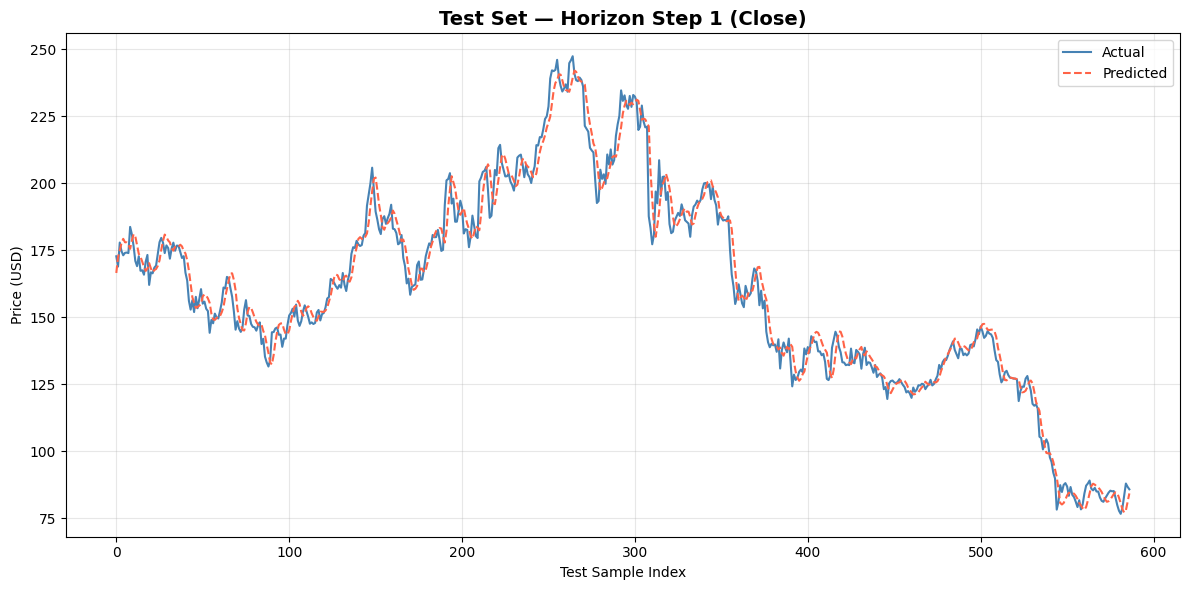

In [3]:
# Create a single plot with the desired size
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting the data
ax.plot(y_test_r[:, 0], label="Actual", color="steelblue", lw=1.5)
ax.plot(y_pred_r[:, 0], label="Predicted", color="tomato", linestyle="--", lw=1.5)

# Formatting
ax.set_title("Test Set — Horizon Step 1 (Close)", fontsize=14, fontweight='bold')
ax.set_xlabel("Test Sample Index")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Save and show
plt.tight_layout()
plt.savefig("sol_lstm.png", dpi=150, bbox_inches="tight")
plt.show()


✅ Model loaded  →  sol_lstm.keras
✅ Data loaded   →  3,978 rows
   Last bar      →  2026-02-28 12:00:00  |  Close = $84.2900

  SOL/USDT Prediction  —  2026-03-25 22:13 UTC
  Current Close  :  $84.2900
──────────────────────────────────────────────────────
  Step    Timestamp                    Price      Change
──────────────────────────────────────────────────────
  +1      2026-03-01 00:00:00     $  84.5397  ▲  0.30%
  +2      2026-03-01 12:00:00     $  83.5579  ▼  0.87%
  +3      2026-03-02 00:00:00     $  81.9397  ▼  2.79%
  +4      2026-03-02 12:00:00     $  81.7596  ▼  3.00%
  +5      2026-03-03 00:00:00     $  84.7912  ▲  0.59%
  +6      2026-03-03 12:00:00     $  85.1276  ▲  0.99%
  +7      2026-03-04 00:00:00     $  85.7543  ▲  1.74%
  +8      2026-03-04 12:00:00     $  88.9825  ▲  5.57%
  +9      2026-03-05 00:00:00     $  86.8409  ▲  3.03%
  +10     2026-03-05 12:00:00     $  86.4977  ▲  2.62%


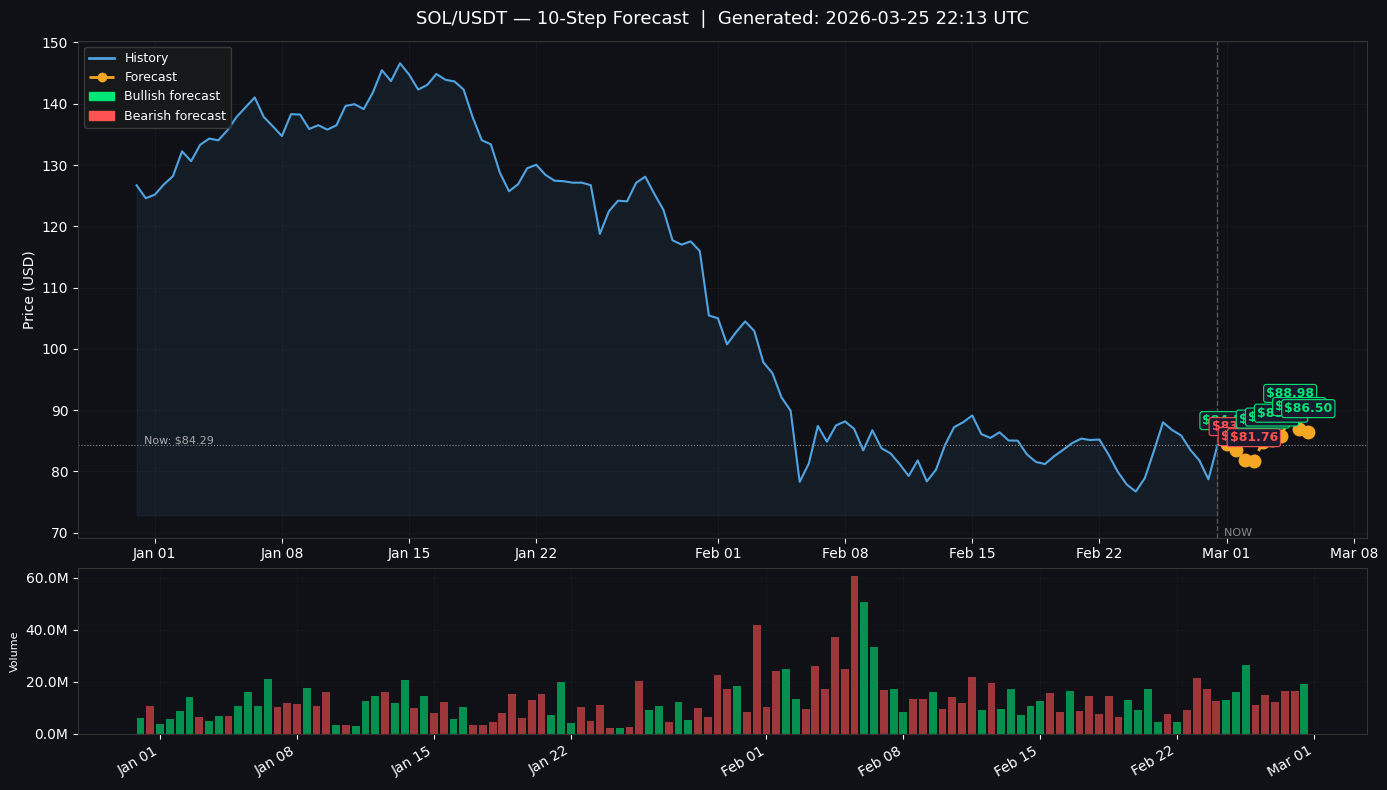


✅ Chart saved  →  sol_prediction_now.png


In [ ]:
# ============================================================
#  SOL/USDT — Real-Time Prediction from Saved LSTM Model
#  Run this anytime to get future price predictions + graph
# ============================================================

# ── CONFIG ───────────────────────────────────────────────────
CSV_PATH   = "SOL_Historical_Master.csv"   # your data file
MODEL_PATH = "sol_lstm.keras"              # saved model
HORIZON    = 5                             # steps to predict (2–5)
LOOKBACK   = 60                            # must match training value
HIST_BARS  = 120                           # bars of history to show on graph
# ─────────────────────────────────────────────────────────────

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from tensorflow.keras.models import load_model

FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]
TARGET_COL   = "Close"
BAR_FREQ     = pd.Timedelta("12h")


# ════════════════════════════════════════════════════════════
#  STEP 1 — Load model
# ════════════════════════════════════════════════════════════
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found at '{MODEL_PATH}'.\n"
        f"Run the training notebook first to generate it."
    )

model = load_model(MODEL_PATH)
print(f"✅ Model loaded  →  {MODEL_PATH}")


# ════════════════════════════════════════════════════════════
#  STEP 2 — Load & scale data
# ════════════════════════════════════════════════════════════
df = pd.read_csv(CSV_PATH, parse_dates=["Open_Time"])
df = df.sort_values("Open_Time").reset_index(drop=True)
df = df.dropna(subset=FEATURE_COLS)

raw    = df[FEATURE_COLS].values.astype(np.float32)
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit_transform(raw)   # fit on full data to restore scaler state

print(f"✅ Data loaded   →  {len(df):,} rows")
print(f"   Last bar      →  {df['Open_Time'].iloc[-1]}  |  Close = ${df['Close'].iloc[-1]:.4f}")


# ════════════════════════════════════════════════════════════
#  STEP 3 — Build last window & predict
# ════════════════════════════════════════════════════════════
close_idx   = FEATURE_COLS.index(TARGET_COL)
scaled_full = scaler.transform(raw)
last_window = scaled_full[-LOOKBACK:][np.newaxis]        # (1, 60, 5)

fut_scaled  = model.predict(last_window, verbose=0)      # (1, HORIZON)

# Inverse-transform Close only
def inv_close(values_1d):
    dummy = np.zeros((len(values_1d), len(FEATURE_COLS)))
    dummy[:, close_idx] = values_1d
    return scaler.inverse_transform(dummy)[:, close_idx]

fut_prices = inv_close(fut_scaled[0])                    # (HORIZON,)

# Build future timestamps
last_ts      = df["Open_Time"].iloc[-1]
future_times = [last_ts + BAR_FREQ * (i + 1) for i in range(HORIZON)]
now          = datetime.utcnow()


# ════════════════════════════════════════════════════════════
#  STEP 4 — Print results
# ════════════════════════════════════════════════════════════
current_price = df["Close"].iloc[-1]
print(f"\n{'='*54}")
print(f"  SOL/USDT Prediction  —  {now.strftime('%Y-%m-%d %H:%M UTC')}")
print(f"{'='*54}")
print(f"  Current Close  :  ${current_price:.4f}")
print(f"{'─'*54}")
print(f"  {'Step':<6}  {'Timestamp':<22}  {'Price':>10}  {'Change':>10}")
print(f"{'─'*54}")
for i, (ts, price) in enumerate(zip(future_times, fut_prices)):
    change    = price - current_price
    change_pct = (change / current_price) * 100
    arrow     = "▲" if change >= 0 else "▼"
    print(f"  +{i+1:<5}  {str(ts):<22}  ${price:>9.4f}  "
          f"{arrow} {abs(change_pct):>5.2f}%")
print(f"{'='*54}")


# ════════════════════════════════════════════════════════════
#  STEP 5 — Plot
# ════════════════════════════════════════════════════════════
hist_times  = df["Open_Time"].values[-HIST_BARS:]
hist_prices = df["Close"].values[-HIST_BARS:]

fig, (ax_main, ax_vol) = plt.subplots(
    2, 1, figsize=(14, 8),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=False
)
fig.patch.set_facecolor("#0f1117")
for ax in [ax_main, ax_vol]:
    ax.set_facecolor("#0f1117")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

# ── Main price chart ─────────────────────────────────────────
ax_main.plot(hist_times, hist_prices,
             color="#4fa3e0", lw=1.5, label="SOL/USDT Close")
ax_main.fill_between(hist_times, hist_prices,
                     hist_prices.min() * 0.95,
                     alpha=0.08, color="#4fa3e0")

# Connect last real bar to first forecast with dashed bridge
bridge_x = [hist_times[-1], future_times[0]]
bridge_y = [hist_prices[-1], fut_prices[0]]
ax_main.plot(bridge_x, bridge_y, "--", color="#888", lw=1, alpha=0.6)

# Forecast line
ax_main.plot(future_times, fut_prices,
             "o--", color="#f5a623", lw=2, markersize=9,
             label=f"Forecast (+{HORIZON} × 12h)")

# Price labels on forecast dots
for ts, p in zip(future_times, fut_prices):
    color = "#00e676" if p >= current_price else "#ff5252"
    ax_main.annotate(
        f"${p:.2f}",
        xy=(ts, p),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center", fontsize=9,
        fontweight="bold", color=color,
        bbox=dict(boxstyle="round,pad=0.2", fc="#1a1a2e", ec=color, lw=0.8)
    )

# Current price horizontal line
ax_main.axhline(current_price, color="#888", lw=0.8, linestyle=":")
ax_main.text(
    hist_times[0], current_price,
    f"  Now: ${current_price:.2f}",
    color="#aaa", fontsize=8, va="bottom"
)

# Vertical "NOW" line
ax_main.axvline(hist_times[-1], color="#555", lw=1, linestyle="--")
ax_main.text(
    hist_times[-1], ax_main.get_ylim()[0],
    "  NOW", color="#888", fontsize=8, va="bottom"
)

ax_main.set_title(
    f"SOL/USDT — {HORIZON}-Step Forecast  |  "
    f"Generated: {now.strftime('%Y-%m-%d %H:%M UTC')}",
    color="white", fontsize=13, pad=12
)
ax_main.set_ylabel("Price (USD)", color="white")
ax_main.legend(facecolor="#1a1a1a", edgecolor="#444",
               labelcolor="white", fontsize=9)
ax_main.grid(True, alpha=0.15, color="#444")
ax_main.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Volume bar chart ──────────────────────────────────────────
vol_colors = ["#00e676" if df["Close"].values[-(HIST_BARS - i)] >=
              df["Open"].values[-(HIST_BARS - i)] else "#ff5252"
              for i in range(HIST_BARS)]
ax_vol.bar(hist_times, df["Volume"].values[-HIST_BARS:],
           color=vol_colors, alpha=0.6, width=0.4)
ax_vol.set_ylabel("Volume", color="white", fontsize=8)
ax_vol.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)
ax_vol.grid(True, alpha=0.1, color="#444")
ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax_vol.xaxis.get_majorticklabels(), rotation=30, ha="right")

# ── Legend patch for forecast area ───────────────────────────
up_patch   = mpatches.Patch(color="#00e676", label="Bullish forecast")
down_patch = mpatches.Patch(color="#ff5252", label="Bearish forecast")
ax_main.legend(
    handles=[
        plt.Line2D([0], [0], color="#4fa3e0", lw=2, label="History"),
        plt.Line2D([0], [0], color="#f5a623", lw=2,
                   linestyle="--", marker="o", label=f"Forecast"),
        up_patch, down_patch,
    ],
    facecolor="#1a1a1a", edgecolor="#444",
    labelcolor="white", fontsize=9, loc="upper left"
)

plt.tight_layout(h_pad=0.5)
out_file = "sol_prediction_now.png"
plt.savefig(out_file, dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"\n✅ Chart saved  →  {out_file}")

In [17]:
# Save the scaler to a file after you fit it!
joblib.dump(scaler, 'sol_scaler.pkl')
print("Scaler saved → sol_scaler.pkl")

Scaler saved → sol_scaler.pkl


In [18]:
'''import os, warnings
import pandas as pd
import numpy as np
import yfinance as yf
import joblib

warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# ── 1. CONFIG ───────────────────────────────────────────────
LOOKBACK = 60
HORIZON = 5       # ⚠️ MUST MATCH the output shape of your saved model!
FINE_TUNE_EPOCHS = 30
FINE_TUNE_LR = 1e-4 # Extremely small learning rate to preserve old memories
FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]

# ── 2. LOAD PRIOR MODEL & SCALER ────────────────────────────
print("1. Loading prior trained model and scaler...")
model = load_model("sol_lstm.keras")
scaler = joblib.load("sol_scaler.pkl")
close_idx = FEATURE_COLS.index("Close")

model.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR), loss="mse")

# ── 3. FETCH LIVE DATA (Bypassing Binance blocks) ───────────
print("2. Fetching live data via Yahoo Finance...")

# Fetch ~130 days of 1-hour data to ensure we have enough to build 120 days of 12h bars
df_yf = yf.download("SOL-USD", period="130d", interval="1h", progress=False)

# Flatten columns if yfinance returns a MultiIndex
if isinstance(df_yf.columns, pd.MultiIndex):
    df_yf.columns = df_yf.columns.get_level_values(0)

# Resample 1-hour bars into perfect 12-hour bars (00:00 and 12:00)
df = df_yf.resample('12h').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

# Format the datetime column
df = df.reset_index()
df.rename(columns={'Datetime': 'Open_time', 'index': 'Open_time', 'Date': 'Open_time'}, inplace=True)
df['Open_time'] = df['Open_time'].dt.tz_localize(None) # Remove timezone for cleaner math

# Keep exactly the last 240 bars (120 days)
df = df.tail(240).copy()
df.reset_index(drop=True, inplace=True)

for col in FEATURE_COLS:
    df[col] = df[col].astype(float)

print(f"   ✓ Built {len(df)} 12-hour bars from {df['Open_time'].min().date()} to {df['Open_time'].max().date()}")

# ── 4. SCALE & BUILD RECENT SEQUENCES ───────────────────────
print("3. Preparing data for fine-tuning...")
raw_data = df[FEATURE_COLS].values.astype(np.float32)

# ⚠️ CRITICAL: We TRANSFORM using the old scaler!
scaled_data = scaler.transform(raw_data)

X_list, y_list = [], []
for i in range(len(scaled_data) - LOOKBACK - HORIZON + 1):
    X_list.append(scaled_data[i : i + LOOKBACK])
    y_list.append(scaled_data[i + LOOKBACK : i + LOOKBACK + HORIZON, close_idx])

X_finetune = np.array(X_list, dtype=np.float32)
y_finetune = np.array(y_list, dtype=np.float32)

# ── 5. FINE-TUNE THE MODEL ──────────────────────────────────
print(f"4. Fine-tuning model on {len(X_finetune)} recent sequences...")
model.fit(X_finetune, y_finetune, epochs=FINE_TUNE_EPOCHS, batch_size=16, verbose=1)

# ── 6. INFERENCE (PREDICT THE FUTURE) ───────────────────────
print("\n5. Generating Forecast...")
# Grab the absolute last 60 bars of the freshly fetched data
last_window = scaled_data[-LOOKBACK:][np.newaxis, ...]

future_scaled = model.predict(last_window, verbose=0)

def inv_close_live(values):
    flat = values.reshape(-1)
    dummy = np.zeros((len(flat), len(FEATURE_COLS)))
    dummy[:, close_idx] = flat
    return scaler.inverse_transform(dummy)[:, close_idx]

future_prices_usd = inv_close_live(future_scaled[0])

# ── 7. DISPLAY RESULTS ──────────────────────────────────────
last_date = df['Open_time'].iloc[-1]
current_price = df['Close'].iloc[-1]

print(f"\n=======================================================")
print(f" 🚀 FINE-TUNED LIVE FORECAST")
print(f"=======================================================")
print(f" Current Data Limit: {last_date.strftime('%b %d, %H:%M')}")
print(f" Current Price:      ${current_price:.2f}")
print("-------------------------------------------------------")

for i, price in enumerate(future_prices_usd):
    future_date = last_date + pd.Timedelta(hours=12 * (i + 1))
    print(f" Step {i+1:02d} | {future_date.strftime('%b %d, %H:%M')}  →  ≈ ${price:.2f}")
print("=======================================================")

1. Loading prior trained model and scaler...
2. Fetching live data via Yahoo Finance...
   ✓ Built 240 12-hour bars from 2025-11-25 to 2026-03-25
3. Preparing data for fine-tuning...
4. Fine-tuning model on 176 recent sequences...
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 2.6823 - mae: 1.5592
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.5672 - mae: 1.5235
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 2.4409 - mae: 1.4859
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 2.3117 - mae: 1.4390
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 2.2270 - mae: 1.4156
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 2.1423 - mae: 1.3871
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 2.0386 - mae: 1.3440
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.8769 - mae: 1.2874
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1.7732 - mae: 1.2493
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/st

In [10]:
import os, warnings
import pandas as pd
import numpy as np
import requests
from sklearn.preprocessing import StandardScaler # Changed to create a new scaler

warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# ── 1. CONFIG ───────────────────────────────────────────────
LOOKBACK = 60
HORIZON = 5          # 5 steps * 12h = 2.5 days
FINE_TUNE_EPOCHS = 30 # REDUCED: 100 is too high for 176 samples (causes overfitting)
FINE_TUNE_LR = 1e-3   # Gentle learning rate
FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]
close_idx = FEATURE_COLS.index("Close")

# ── 2. LOAD PRIOR MODEL ─────────────────────────────────────
print("1. Loading prior trained model...")
model = load_model("sol_lstm.keras")
model.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR), loss="mse")

# ── 3. FETCH LIVE DATA VIA BINANCE ──────────────────────────
def fetch_historical_data(symbol="SOLUSDT", interval="12h", limit=1000):
    print(f"2. Fetching historical {interval} data for {symbol} from Binance...")

    url = "https://api.binance.us/api/v3/klines"     # US Server
    params = {"symbol": symbol, "interval": interval, "limit": limit}

    response = requests.get(url, params=params)
    if response.status_code != 200:
        # Fallback to global if US fails
        url = "https://api.binance.com/api/v3/klines"
        response = requests.get(url, params=params)

    data = response.json()

    df = pd.DataFrame(data, columns=[
        "Open_time", "Open", "High", "Low", "Close", "Volume",
        "Close_time", "Quote_asset_volume", "Number_of_trades",
        "Taker_buy_base_v", "Taker_buy_quote_v", "Ignore"
    ])

    df["Open_time"] = pd.to_datetime(df["Open_time"], unit="ms")
    for col in FEATURE_COLS:
        df[col] = pd.to_numeric(df[col]).astype(float)

    df = df[["Open_time"] + FEATURE_COLS]
    return df

df = fetch_historical_data()

# ── 4. DYNAMIC SCALING (THE FIX) ────────────────────────────
print("3. Preparing data and updating Scaler...")

# FIX: We fit a NEW scaler on the recent 1000 bars.
# The neural network looks for *patterns and shapes* (momentum, dips), not raw dollars.
# Scaling current prices down to standard ranges prevents the LSTM from breaking.
scaler = StandardScaler()
raw_all_data = df[FEATURE_COLS].values.astype(np.float32)
scaler.fit(raw_all_data)

# Grab the fine-tune window
df_finetune = df.tail(240).copy().reset_index(drop=True)
raw_finetune_data = df_finetune[FEATURE_COLS].values.astype(np.float32)

# Transform using the NEWly fitted scaler
scaled_data = scaler.transform(raw_finetune_data)

X_list, y_list = [], []
for i in range(len(scaled_data) - LOOKBACK - HORIZON + 1):
    X_list.append(scaled_data[i : i + LOOKBACK])
    y_list.append(scaled_data[i + LOOKBACK : i + LOOKBACK + HORIZON, close_idx])

X_finetune = np.array(X_list, dtype=np.float32)
y_finetune = np.array(y_list, dtype=np.float32)

# ── 5. FINE-TUNE THE MODEL ──────────────────────────────────
print(f"4. Fine-tuning model on {len(X_finetune)} recent sequences...")
model.fit(X_finetune, y_finetune, epochs=FINE_TUNE_EPOCHS, batch_size=16, verbose=1)

# ── 6. INFERENCE (PREDICT THE FUTURE) ───────────────────────
print("\n5. Generating Forecast...")
# Grab the absolute last 60 bars of the data
last_window = scaled_data[-LOOKBACK:][np.newaxis, ...]

future_scaled = model.predict(last_window, verbose=0)

def inv_close_live(values):
    flat = values.reshape(-1)
    dummy = np.zeros((len(flat), len(FEATURE_COLS)))
    dummy[:, close_idx] = flat
    return scaler.inverse_transform(dummy)[:, close_idx]

future_prices_usd = inv_close_live(future_scaled[0])

# ── 7. DISPLAY RESULTS ──────────────────────────────────────
last_date = df_finetune['Open_time'].iloc[-1]
current_price = df_finetune['Close'].iloc[-1]

print(f"\n=======================================================")
print(f" 🚀 FINE-TUNED LIVE FORECAST (SOL/USDT)")
print(f"=======================================================")
print(f" Current Data Limit: {last_date.strftime('%b %d, %H:%M')} UTC")
print(f" Current Price:      ${current_price:.2f}")
print("-------------------------------------------------------")

for i, price in enumerate(future_prices_usd):
    future_date = last_date + pd.Timedelta(hours=12 * (i + 1))
    print(f" Step {i+1:02d} | {future_date.strftime('%b %d, %H:%M')}  →  ≈ ${price:.2f}")
print("=======================================================")

1. Loading prior trained model...
2. Fetching historical 12h data for SOLUSDT from Binance...
3. Preparing data and updating Scaler...
4. Fine-tuning model on 176 recent sequences...
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 1.8899 - mae: 1.3036
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.7869 - mae: 0.7535
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.2859 - mae: 0.4282
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2433 - mae: 0.3732
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2698 - mae: 0.3959
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1043 - mae: 0.2459
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1744 - mae: 0.3247
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1298 - mae: 0.2794
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1977 - mae: 0.3530
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1187 - mae: 0.2726
Epoch 11/30
11/1

   ✓ Chart saved as forecast_20260325_1200.png


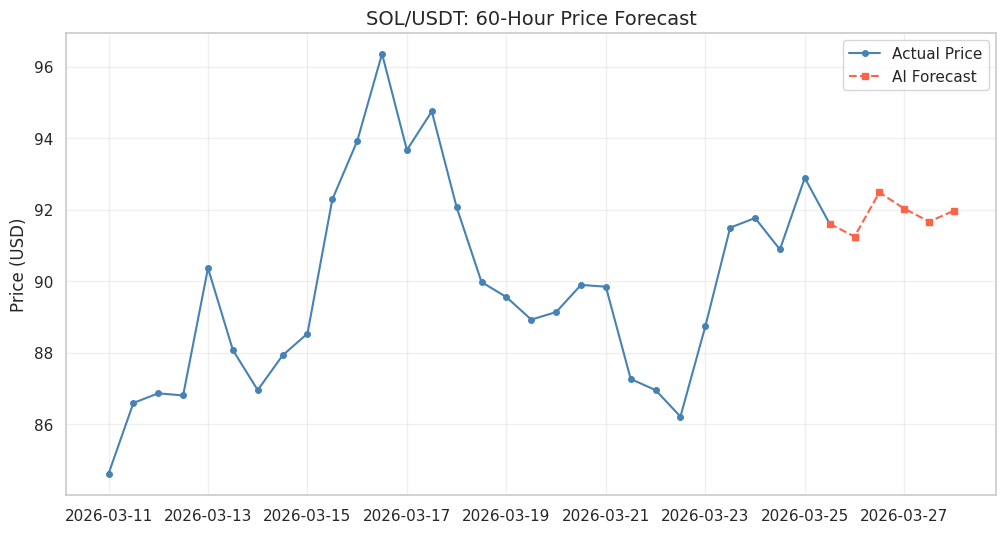

In [15]:
import matplotlib.pyplot as plt

def plot_forecast(df, future_prices, symbol="SOL"):
    plt.figure(figsize=(12, 6))

    # 1. Plot last 30 actual data points
    recent_actual = df.tail(30)
    plt.plot(recent_actual['Open_time'], recent_actual['Close'],
             label="Actual Price", color="steelblue", marker='o', markersize=4)

    # 2. Create timeline for the forecast
    last_date = recent_actual['Open_time'].iloc[-1]
    future_dates = [last_date + pd.Timedelta(hours=12 * (i + 1)) for i in range(len(future_prices))]

    # 3. Plot forecast (connected to the last actual price)
    plt.plot([last_date] + future_dates, [recent_actual['Close'].iloc[-1]] + list(future_prices),
             label="AI Forecast", color="tomato", linestyle="--", marker='s', markersize=4)

    plt.title(f"{symbol}/USDT: 60-Hour Price Forecast", fontsize=14)
    plt.ylabel("Price (USD)")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Save with a timestamp
    timestamp = last_date.strftime('%Y%m%d_%H%M')
    plt.savefig(f"forecast_{timestamp}.png", dpi=150)
    print(f"   ✓ Chart saved as forecast_{timestamp}.png")
    plt.show()

# Call it after your prediction loop
plot_forecast(df_finetune, future_prices_usd)
